# <div align="center"><u>Project 4 - DBSCAN Clustering</u>
    
    - Density-Based Spatial Clustering of Applications with Noise

##############################################################################################################################

###  Import libraries

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import time

from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from sklearn.neighbors import NearestNeighbors

### Suppress warnings

In [113]:
# Suppress all warnings
import warnings

warnings.filterwarnings("ignore")

### Start time

In [114]:
# Start time
start_time = time.time()

### Load the final dataset and store it within a pandas DataFrame

In [115]:
# Load the final dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\VAVOULIDIS MILTIADIS - ZACHARIAS\Projects\Project 4\final_dataset.csv")

# Print the dataset
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,V29,V30,Class
0,1.176800,-2.121200,1.357375,1.184085,1.618861,2.541404,2.647422,2.620973,2.348535,2.511708,...,-1.375159,2.439568,2.287627,1.344848,2.641905,2.246192,2.296076,2.443918,2.225247,2
1,1.949929,-0.354875,1.795991,2.249396,-0.842995,-0.498189,-0.000497,0.574944,0.017882,-0.925449,...,-0.370048,1.631542,2.287627,-0.377098,-0.443388,-0.137634,1.087084,-0.234408,0.355314,2
2,1.686226,0.476899,1.670052,1.846217,0.975239,1.148680,1.496076,2.110330,1.004666,-0.407692,...,-0.019582,1.434234,1.807751,0.546654,1.223448,0.920718,1.955000,1.369057,0.265197,2
3,-0.791983,0.268955,-0.606410,-0.831485,2.737521,2.541404,2.091997,1.506601,2.521318,2.517947,...,0.140773,-0.245395,-0.593838,2.595949,2.641905,2.119474,2.175786,2.443918,2.482456,2
4,1.866023,-1.174698,1.891531,2.154338,0.295047,0.599453,1.504202,1.482665,0.006363,-0.588595,...,-1.484267,1.424838,1.525780,0.232758,-0.314469,0.665254,0.729259,-0.951602,-0.410683,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.246595,0.749377,2.191180,2.250380,1.077633,0.256947,2.125856,2.402886,-0.312326,-0.994068,...,0.124241,1.860170,2.287627,0.394190,-0.270329,0.719489,1.629151,-1.516438,-0.763016,2
565,1.818077,2.150007,1.722165,2.036334,0.112199,0.003614,0.772845,1.312717,-0.212495,-1.134424,...,2.083216,1.512531,1.854045,-0.699963,-0.404152,0.267358,0.733827,-0.565135,-1.062155,2
566,0.760269,2.109375,0.727678,0.715676,-0.856891,-0.018680,0.075483,0.118824,-0.834515,-0.955080,...,1.400468,0.626208,0.576760,-0.821037,0.417005,0.362650,0.414069,-1.222872,-0.321817,2
567,1.958919,2.408144,2.108668,2.049446,1.574978,2.541404,2.647422,2.751293,2.264063,1.178328,...,2.276634,2.439568,2.043428,1.470406,2.641905,2.619251,2.289985,2.249756,2.482456,2


### Split features and true label

In [116]:
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column ("Class")

### Set parameters for fine tuning

In [117]:
# Define the ranges for eps and min_samples you want to test
eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 8.0, 10.0]
min_samples_values = [2, 3, 5, 7, 10, 15, 20, 30]

# Initialize a list to hold results
results = []

# print(f"{'eps':<6} | {'min_samp':<8} | {'Clusters':<8} | {'Noise':<6} | {'ARI':<6} | {'NMI':<6}")
# print("-" * 55)

### Apply DBSCAN

In [118]:
### Apply DBSCAN - Nested loop to try every combination
for eps in eps_values:
    for min_samples in min_samples_values:
        
        # Apply DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X)
        
        # Calculate cluster and noise counts
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)
        
        # If DBSCAN groups everything into 1 cluster or calls everything noise, 
        # the scores might be misleadingly low/exceptional, so we keep track of counts.
        ari = adjusted_rand_score(y, clusters)
        nmi = normalized_mutual_info_score(y, clusters)
        
        # Save results
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'ARI': ari,
            'NMI': nmi
        })
        
        print(f"{eps:<6.1f} | {min_samples:<8d} | {n_clusters:<8d} | {n_noise:<6d} | {ari:<6.3f} | {nmi:<6.3f}")

# Convert results to a DataFrame for easy handling
df_results = pd.DataFrame(results)

2.0    | 2        | 25       | 383    | 0.020  | 0.183 
2.0    | 3        | 5        | 423    | 0.008  | 0.182 
2.0    | 5        | 3        | 459    | -0.016 | 0.157 
2.0    | 7        | 2        | 483    | -0.037 | 0.124 
2.0    | 10       | 1        | 498    | -0.039 | 0.122 
2.0    | 15       | 1        | 534    | -0.035 | 0.067 
2.0    | 20       | 0        | 569    | 0.000  | 0.000 
2.0    | 30       | 0        | 569    | 0.000  | 0.000 
2.5    | 2        | 22       | 246    | 0.176  | 0.192 
2.5    | 3        | 6        | 278    | 0.169  | 0.184 
2.5    | 5        | 4        | 314    | 0.177  | 0.234 
2.5    | 7        | 3        | 328    | 0.177  | 0.242 
2.5    | 10       | 2        | 361    | 0.157  | 0.263 
2.5    | 15       | 1        | 397    | 0.098  | 0.237 
2.5    | 20       | 1        | 403    | 0.083  | 0.227 
2.5    | 30       | 1        | 436    | 0.020  | 0.185 
3.0    | 2        | 16       | 120    | 0.109  | 0.100 
3.0    | 3        | 4        | 144    | 0.104  |

### Plot the results

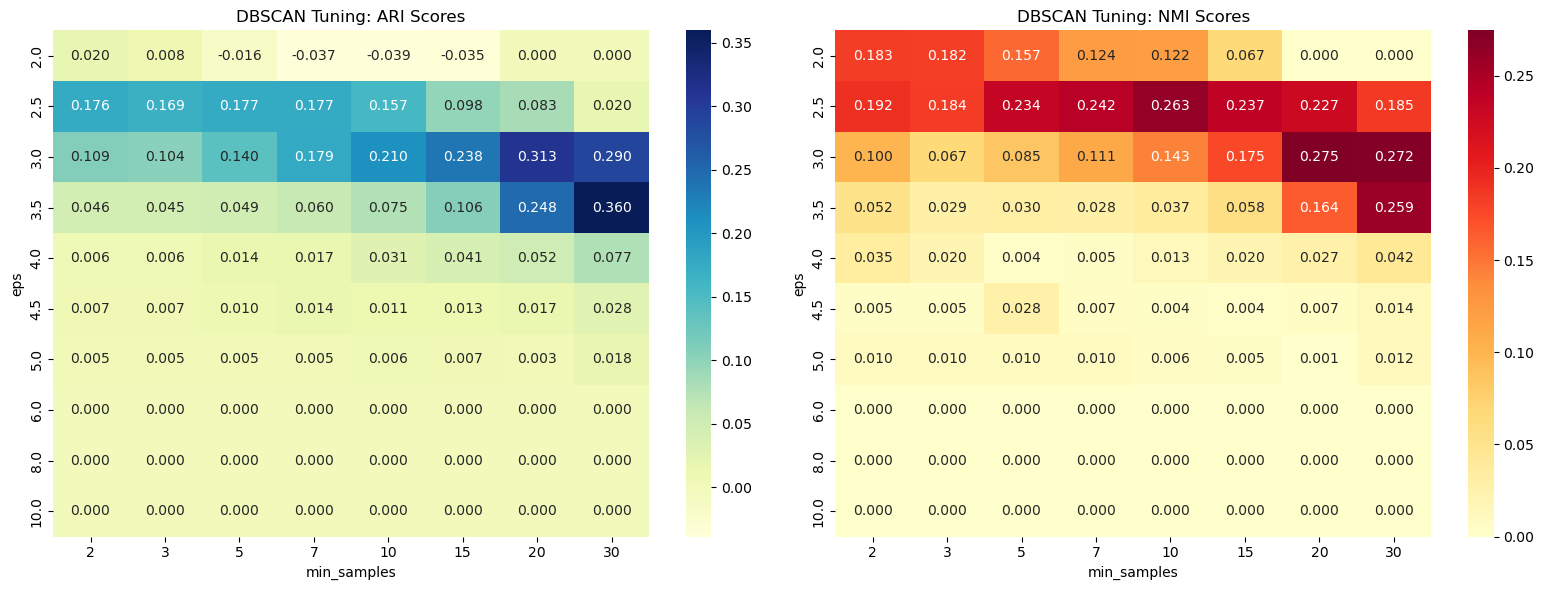

In [119]:
# Plot Heatmaps to visualize the parameter grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pivot data for heatmap formatting
ari_pivot = df_results.pivot(index='eps', columns='min_samples', values='ARI')
nmi_pivot = df_results.pivot(index='eps', columns='min_samples', values='NMI')

# Plot ARI Heatmap
sns.heatmap(ari_pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title('DBSCAN Tuning: ARI Scores')
axes[0].set_ylabel('eps')
axes[0].set_xlabel('min_samples')

# Plot NMI Heatmap
sns.heatmap(nmi_pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title('DBSCAN Tuning: NMI Scores')
axes[1].set_ylabel('eps')
axes[1].set_xlabel('min_samples')

plt.tight_layout()
plt.show()

### ARI results

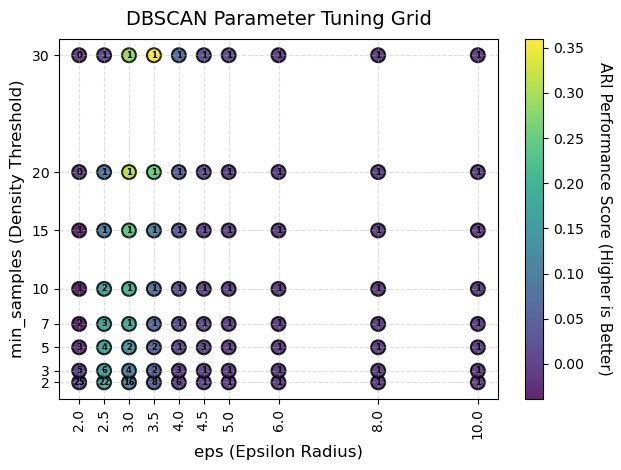

In [120]:
# We map the dot color to ARI score so you know which combination is performing best
scatter = plt.scatter(
    df_results['eps'], 
    df_results['min_samples'], 
    c=df_results['ARI'],       # Color represents the ARI metric
    cmap='viridis',            # Vibrant color scale (yellow = high ARI, purple = low ARI)
    s=100,                     # Make dots large enough to fit text inside
    edgecolors='black', 
    linewidths=1.5,
    alpha=0.85
)

# Add the colorbar for the ARI metric
cbar = plt.colorbar(scatter)
cbar.set_label('ARI Performance Score (Higher is Better)', rotation=270, labelpad=20, fontsize=11)

# Annotate the exact number of clusters inside every single dot
for i in range(len(df_results)):
    plt.text(
        df_results['eps'].iloc[i], 
        df_results['min_samples'].iloc[i], 
        str(int(df_results['n_clusters'].iloc[i])), # Number of clusters text
        color='black', 
        ha='center', 
        va='center', 
        fontweight='bold', 
        fontsize=6
    )

# Formatting the plot cleanly
plt.title('DBSCAN Parameter Tuning Grid', fontsize=14, pad=10)
plt.xlabel('eps (Epsilon Radius)', fontsize=12)
plt.ylabel('min_samples (Density Threshold)', fontsize=12)
plt.xticks(eps_values, rotation = 90)
plt.yticks(min_samples_values)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### NMI results

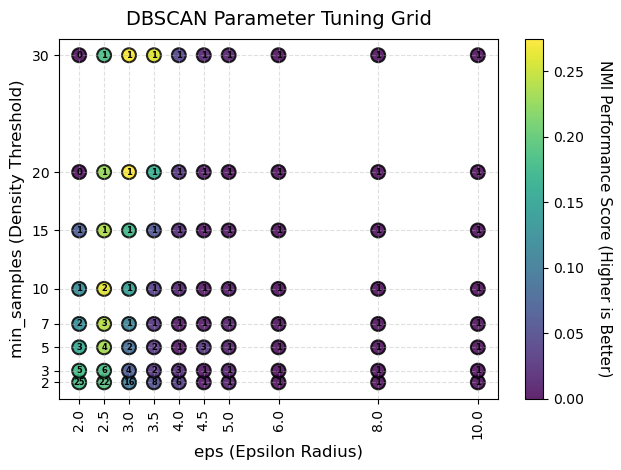

In [121]:
# We map the dot color to ARI score so you know which combination is performing best
scatter = plt.scatter(
    df_results['eps'], 
    df_results['min_samples'], 
    c=df_results['NMI'],       # Color represents the NMI metric
    cmap='viridis',            # Vibrant color scale (yellow = high NMI, purple = low ARI)
    s=100,                     # Make dots large enough to fit text inside
    edgecolors='black', 
    linewidths=1.5,
    alpha=0.85
)

# Add the colorbar for the NMI metric
cbar = plt.colorbar(scatter)
cbar.set_label('NMI Performance Score (Higher is Better)', rotation=270, labelpad=20, fontsize=11)

# Annotate the exact number of clusters inside every single dot
for i in range(len(df_results)):
    plt.text(
        df_results['eps'].iloc[i], 
        df_results['min_samples'].iloc[i], 
        str(int(df_results['n_clusters'].iloc[i])), # Number of clusters text
        color='black', 
        ha='center', 
        va='center', 
        fontweight='bold', 
        fontsize=6
    )

# Formatting the plot cleanly
plt.title('DBSCAN Parameter Tuning Grid', fontsize=14, pad=10)
plt.xlabel('eps (Epsilon Radius)', fontsize=12)
plt.ylabel('min_samples (Density Threshold)', fontsize=12)
plt.xticks(eps_values, rotation = 90)
plt.yticks(min_samples_values)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Evaluate clustering (scientific way)

In [123]:
#  # Calculate scores (evaluate clustering in proper scientific way)
# ari = adjusted_rand_score(y, clusters)
# nmi = normalized_mutual_info_score(y, clusters)

In [124]:
# # Optional: Check how many clusters DBSCAN found (Note: -1 represents noise points)
# n_clusters_ = len(set(clusters)) - (1 if -1 in clusters else 0)
# n_noise_ = list(clusters).count(-1)
# print(f"Estimated number of clusters: {n_clusters_}")
# print(f"Estimated number of noise points: {n_noise_}")

### End time

In [125]:
# End time
end_time = time.time()

### Elapsed time

In [126]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for DBSCAN Clustering fine tuning: {elapsed_time:.2f} seconds")

Elapsed time for DBSCAN Clustering fine tuning: 11.90 seconds


In [127]:
# results_df = pd.DataFrame({
#     "True_Label": y,
#     "Cluster_Label": clusters
# })

# print(results_df.head(20))